# Load AICME From An Experiment Folder

This notebook uses the current AICME PK loading path and current empirical datamodule API.

Workflow:
1. Pick an experiment folder under `results/`.
2. Load `experiment_config.yaml` plus the selected checkpoint.
3. Pull one empirical dataset from the datamodule cache.
4. Select one Study/Drug pair, slice that batch row, and sample predictive trajectories with `AICMEPK.sample_individual_prediction(...)`.
5. Reuse the callback-style VPC pipeline for the same selected Study/Drug pair.


In [6]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pff").exists() and (candidate / "config_files").exists():
            return candidate
    raise RuntimeError("Could not find the project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pff.config_classes.node_pk_config import NodePKExperimentConfig
from pff.data.data_empirical.builder import (
    databatch_to_study_jsons,
    prediction_to_study_jsons,
)
from pff.data.datasets.aicme_datasets import AICMECompartmentsDataModule
from pff.metrics.sampling_quality import compute_vpc_data, vpc_plot
from pff.models.amortized_inference.aicme import AICMEPK
from pff.training.utils import (
    get_lightning_checkpoint_path,
    load_model_from_checkpoint_path,
)
from pff.utils.plots.databatch_plot import plot_study_json_with_prediction

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def discover_experiment_dirs(results_dir: Path) -> list[Path]:
    if not results_dir.exists():
        return []
    candidates = [
        path
        for path in results_dir.iterdir()
        if path.is_dir() and (path / "experiment_config.yaml").exists()
    ]
    return sorted(candidates, key=lambda path: path.stat().st_mtime, reverse=True)

def load_aicme_experiment(
    experiment_dir: Path,
    *,
    checkpoint_type: str = "best",
    map_location: str = "cpu",
) -> tuple[NodePKExperimentConfig, AICMEPK, AICMECompartmentsDataModule, Path]:
    config_path = experiment_dir / "experiment_config.yaml"
    if not config_path.exists():
        raise FileNotFoundError(f"Missing experiment config: {config_path}")

    exp_config = NodePKExperimentConfig.from_yaml(str(config_path))
    checkpoint_path = get_lightning_checkpoint_path(str(experiment_dir), checkpoint_type)
    if checkpoint_path is None:
        raise FileNotFoundError(
            f"Could not find a '{checkpoint_type}' checkpoint inside {experiment_dir}."
        )

    model = load_model_from_checkpoint_path(
        AICMEPK,
        checkpoint_path,
        model_config=exp_config,
        map_location=map_location,
        strict=True,
    )
    model = model.to(map_location)
    model.eval()

    datamodule = AICMECompartmentsDataModule(exp_config)
    datamodule.setup()
    return exp_config, model, datamodule, Path(checkpoint_path)

def normalize_selection_label(label: object) -> str:
    """Normalize Study/Drug labels so notebook selection stays robust."""

    return "".join(ch.lower() for ch in str(label) if ch.isalnum())

In [7]:
#RESULTS_DIR = PROJECT_ROOT / "results"
#AVAILABLE_EXPERIMENT_DIRS = discover_experiment_dirs(RESULTS_DIR)
#AVAILABLE_EXPERIMENT_DIRS[:10]
#EXPERIMENT_DIR = AVAILABLE_EXPERIMENT_DIRS[0] if AVAILABLE_EXPERIMENT_DIRS else None

# Change these values for the experiment/dataset you want to inspect.
EXPERIMENT_DIR = Path("/home/cesarali/Pharma/pff/results/comet/uai/cb906bbb30f34522813c1357fff45371")
CHECKPOINT_TYPE = "log_rmse"  # "best" or "last"
MAP_LOCATION = "cpu"      # "cpu" or "cuda"

NO_HELDOUT = False
DATASET_KEY = None         # Example: "cesarali/lenuzza-2016"
BATCH_INDEX = 1
SELECTED_STUDY = "Lenuzza2016"      # Example: "Lenuzza2016"; use with SELECTED_DRUG for a unique batch row
#SELECTED_DRUG = "midazolam"       # Example: "midazolam"; None -> first drug in the selected batch row
SELECTED_DRUG = "memantine"       # Example: "midazolam"; None -> first drug in the selected batch row
FIX_PAST_TARGET_STEPS = 5  # Example: 5; None keeps the default stochastic past split
SAMPLE_SIZE = 8
PLOT_LOG_SCALE = True
VPC_SAMPLE_SIZE = 8
VPC_N_BINS = 10
VPC_BINNING = "equal_count"
VPC_LOG_SCALE = False


predictive_plot_kwargs = {
    "figure_size": (8, 6),
    "title": None,
    "title_font_size": 19,
    "show_legend": True,
    "legend_font_size": 12,
    "axis_label_font_size": 18,
    "tick_label_font_size": 14,
    "point_size": 32,
    "point_marker": "o",
    "prediction_marker": "o",
    "prediction_marker_size": 9,
    "context_obs_color": "forestgreen",
    "context_rem_color": "mediumseagreen",
}

print(f"Using experiment folder: {EXPERIMENT_DIR}")

Using experiment folder: /home/cesarali/Pharma/pff/results/comet/uai/cb906bbb30f34522813c1357fff45371


In [8]:
exp_config, model, datamodule, checkpoint_path = load_aicme_experiment(
    EXPERIMENT_DIR,
    checkpoint_type=CHECKPOINT_TYPE,
    map_location=MAP_LOCATION,
)

print("Checkpoint:", checkpoint_path)
print("Model:", type(model).__name__)
print("Configured empirical datasets:", exp_config.mix_data.test_empirical_datasets)

Checkpoint: /home/cesarali/Pharma/pff/results/comet/uai/cb906bbb30f34522813c1357fff45371/scheduler_metric_checkpoints/empirical_summary/best-epoch_049-step_0003350-log_rmse=1.523099.ckpt
Model: AICMEPK
Configured empirical datasets: ['cesarali/lenuzza-2016', 'cesarali/Indometacin', 'cesarali/Theophylline']


In [29]:
if FIX_PAST_TARGET_STEPS is not None:
    datamodule.fix_past_selection(FIX_PAST_TARGET_STEPS, who="target")
else:
    datamodule.release_past_selection(who="target")

empirical_batches = datamodule.get_empirical_test_batches(no_heldout=NO_HELDOUT)
available_studies, available_drugs = datamodule.describe_empirical_test_batches(
    empirical_batches=empirical_batches,
    no_heldout=NO_HELDOUT,
    batch_index=BATCH_INDEX,
    print_available=True,
)

print("Number of empirical datasets:", len(empirical_batches))

Available empirical datasets (heldout): ['cesarali/lenuzza-2016', 'cesarali/Indometacin', 'cesarali/Theophylline']
Dataset 'cesarali/lenuzza-2016' contains 10 empirical batch(es).
  Batch 1 studies: ['Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016']
  Batch 1 drugs: ['memantine', 'omeprazole', '5-hydroxyomeprazole', 'omeprazole sulfone', 'repaglinide', 'hydroxy repaglinide', 'rosuvastatin', 'tolbutamide', '4-hydroxytolbutamide', 'dextromethorphan', 'digoxin', 'paracetamol', '1-hydroxymidazolam', 'paracetamol glucuronide', 'dextrorphan', 'caffeine (137X)', 'midazolam', 'paraxanthine (17X)']
Dataset 'cesarali/Indometacin' contains 6 empirical batch(es).
  Batch 1 studies: ['Indometacin']
  Batch 1 drugs: ['Indometacin']
Dataset 'cesarali/Theophylline' contains 12 empirica

In [9]:
def build_batch_selection_table(batch) -> pd.DataFrame:
    """Return one selection row per leading batch element ``B``."""

    studies, drugs = datamodule.describe_empirical_batch(batch, print_available=False)
    return pd.DataFrame(
        {
            "batch_row": list(range(len(drugs))),
            "study": studies,
            "drug": drugs,
        }
    )

def select_batch_row(
    batch,
    *,
    selected_study: str | None = None,
    selected_drug: str | None = None,
) -> tuple[int, str, str, pd.DataFrame]:
    """Resolve one unique batch row from the requested Study/Drug pair."""

    selection_table = build_batch_selection_table(batch)
    matching_rows = selection_table

    if selected_study is not None:
        normalized_study = normalize_selection_label(selected_study)
        matching_rows = matching_rows[
            matching_rows["study"].map(normalize_selection_label) == normalized_study
        ]

    if selected_drug is not None:
        normalized_drug = normalize_selection_label(selected_drug)
        matching_rows = matching_rows[
            matching_rows["drug"].map(normalize_selection_label) == normalized_drug
        ]

    if selected_study is None and selected_drug is None:
        matching_rows = selection_table.iloc[[0]]

    if matching_rows.empty:
        raise ValueError(
            "No Study/Drug match was found in the selected batch. "
            f"Requested study={selected_study!r}, drug={selected_drug!r}.\n"
            f"Choose from:\n{selection_table.to_string(index=False)}"
        )

    if len(matching_rows) > 1:
        raise ValueError(
            "Selection is ambiguous inside the selected batch. "
            "Set both SELECTED_STUDY and SELECTED_DRUG to one unique row.\n"
            f"Matching rows:\n{matching_rows.to_string(index=False)}"
        )

    selected_row = matching_rows.iloc[0]
    selected_batch_index = int(selected_row["batch_row"])
    selected_study_name = str(selected_row["study"])
    selected_drug_name = str(selected_row["drug"])
    return selected_batch_index, selected_study_name, selected_drug_name, selection_table

# Prediction

Saved prediction plot to: /home/cesarali/Pharma/pff/reports/results_aistats/memantine_prediction.pdf


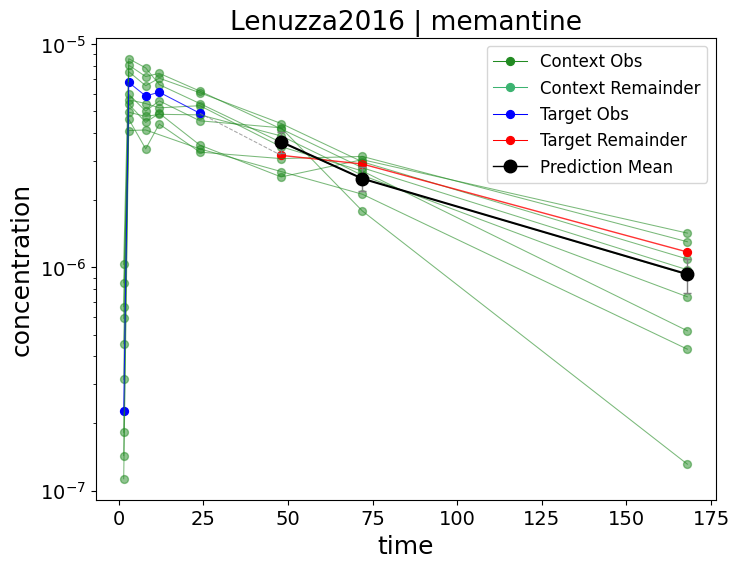

In [10]:
%matplotlib inline
BATCH_INDEX = 1
FIX_PAST_TARGET_STEPS = 5

if FIX_PAST_TARGET_STEPS is not None:
    datamodule.fix_past_selection(FIX_PAST_TARGET_STEPS, who="target")
else:
    datamodule.release_past_selection(who="target")

selected_dataset_key, batch_list = datamodule.select_empirical_batch_list(
    dataset_key=DATASET_KEY,
    no_heldout=NO_HELDOUT,
)
if BATCH_INDEX >= len(batch_list):
    raise IndexError(
        f"BATCH_INDEX={BATCH_INDEX} is out of range for dataset '{selected_dataset_key}' "
        f"with {len(batch_list)} permutation batch(es)."
    )

raw_batch = batch_list[BATCH_INDEX]
selected_batch_index, selected_study, selected_drug, batch_selection_table = select_batch_row(
    raw_batch,
    selected_study=SELECTED_STUDY,
    selected_drug=SELECTED_DRUG,
)
selected_batch = datamodule.slice_single_substance_batch(raw_batch, selected_batch_index)

device = torch.device(MAP_LOCATION)
selected_batch_device = selected_batch.to(device)

with torch.inference_mode():
    prediction_samples, prediction_times, target_future, target_future_mask = (
        model.sample_individual_prediction(
            selected_batch_device,
            sample_size=SAMPLE_SIZE,
        )
    )

prediction_samples_cpu = prediction_samples.detach().cpu()
prediction_times_cpu = prediction_times.detach().cpu()
selected_batch_cpu = selected_batch.to("cpu")

studies_with_predictions = prediction_to_study_jsons(
    prediction_samples_cpu,
    prediction_times_cpu,
    selected_batch_cpu,
    model.meta_dosing,
)
study = studies_with_predictions[0]

render_kwargs = dict(predictive_plot_kwargs)
figure_size = tuple(render_kwargs.pop("figure_size", (8, 6)))
title = render_kwargs.pop("title", None)
title_font_size = render_kwargs.pop("title_font_size", None)

fig, ax = plt.subplots(figsize=figure_size)
plot_study_json_with_prediction(
    study,
    ax=ax,
    log_scale=PLOT_LOG_SCALE,
    **render_kwargs,
)
resolved_title = title or f"{study['meta_data']['study_name']} | {study['meta_data']['substance_name']}"
if title_font_size is not None:
    ax.set_title(resolved_title, fontsize=float(title_font_size))
else:
    ax.set_title(resolved_title)

prediction_output_dir = PROJECT_ROOT / "reports" / "results_aistats"
prediction_output_dir.mkdir(parents=True, exist_ok=True)
prediction_plot_name = "".join(
    ch if ch.isalnum() or ch in (" ", "-", "_", "(", ")") else "_"
    for ch in str(study["meta_data"]["substance_name"])
).strip()
prediction_plot_path = prediction_output_dir / f"{prediction_plot_name}_prediction.pdf"
fig.savefig(prediction_plot_path, format="pdf", bbox_inches="tight")
print("Saved prediction plot to:", prediction_plot_path)
plt.show()


VPC selected batch row: 6
VPC selected study: Lenuzza2016
VPC selected drug: rosuvastatin
Available Study/Drug rows in VPC source batch:
 batch_row       study                    drug
         0 Lenuzza2016               memantine
         1 Lenuzza2016              omeprazole
         2 Lenuzza2016     5-hydroxyomeprazole
         3 Lenuzza2016      omeprazole sulfone
         4 Lenuzza2016             repaglinide
         5 Lenuzza2016     hydroxy repaglinide
         6 Lenuzza2016            rosuvastatin
         7 Lenuzza2016             tolbutamide
         8 Lenuzza2016    4-hydroxytolbutamide
         9 Lenuzza2016        dextromethorphan
        10 Lenuzza2016                 digoxin
        11 Lenuzza2016             paracetamol
        12 Lenuzza2016      1-hydroxymidazolam
        13 Lenuzza2016 paracetamol glucuronide
        14 Lenuzza2016             dextrorphan
        15 Lenuzza2016         caffeine (137X)
        16 Lenuzza2016               midazolam
        17 Lenuzz

/home/cesarali/Pharma/pff/pff/metrics/sampling_quality.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed_values.groupby("Time")["Value"]
/home/cesarali/Pharma/pff/pff/metrics/sampling_quality.py:281: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  predicted_values.groupby(["Time", "Replicate"])["Value"]
/home/cesarali/Pharma/pff/pff/metrics/sampling_quality.py:286: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

Saved VPC plot to: /home/cesarali/Pharma/pff/reports/results_aistats/rosuvastatin.pdf


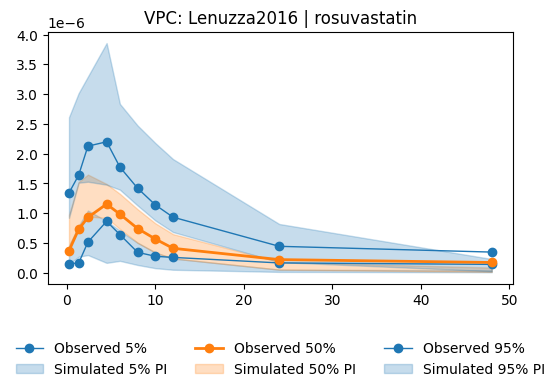

,Time,Quantile,Obs,LowerPred,UpperPred
0,0.250000,0.05,1.533465e-07,1.440672e-07,4.483537e-07
1,0.250000,0.50,3.681653e-07,4.551053e-07,9.741056e-07
2,0.250000,0.95,1.339671e-06,9.213016e-07,2.610359e-06
3,1.340909,0.05,1.601936e-07,2.668906e-07,7.863796e-07
4,1.340909,0.50,7.275312e-07,7.680176e-07,1.523206e-06


In [18]:
#Dataset 'cesarali/lenuzza-2016' contains 10 empirical batch(es).
#  Batch 1 studies: ['Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016']
#  Batch 1 drugs: ['memantine', 'omeprazole', '5-hydroxyomeprazole', 'omeprazole sulfone', 'repaglinide', 'hydroxy repaglinide', 'rosuvastatin', 'tolbutamide', '4-hydroxytolbutamide', 'dextromethorphan', 'digoxin', 'paracetamol', '1-hydroxymidazolam', 'paracetamol glucuronide', 'dextrorphan', 'caffeine (137X)', 'midazolam', 'paraxanthine (17X)']

BATCH_INDEX = 0
VPC_SAMPLE_SIZE = 100
DATASET_KEY = "cesarali/lenuzza-2016"
SELECTED_STUDY = "Lenuzza-2016"
SELECTED_DRUG = "rosuvastatin"

selected_dataset_key, batch_list = datamodule.select_empirical_batch_list(
    dataset_key=DATASET_KEY,
    no_heldout=NO_HELDOUT,
)

raw_batch = batch_list[BATCH_INDEX]
selected_batch_index, selected_study, selected_drug, batch_selection_table = select_batch_row(
    raw_batch,
    selected_study=SELECTED_STUDY,
    selected_drug=SELECTED_DRUG,
)
selected_batch = datamodule.slice_single_substance_batch(raw_batch, selected_batch_index)


# VPC uses the no-heldout cache so observed and simulated StudyJSON keys match.
selected_dataset_key_vpc, batch_list_vpc = datamodule.select_empirical_batch_list(
    dataset_key=selected_dataset_key,
    no_heldout=True,
)
if BATCH_INDEX >= len(batch_list_vpc):
    raise IndexError(
        f"BATCH_INDEX={BATCH_INDEX} is out of range for no-heldout dataset "
        f"'{selected_dataset_key_vpc}' with {len(batch_list_vpc)} permutation batch(es)."
    )

raw_batch_vpc = batch_list_vpc[BATCH_INDEX]
selected_batch_index_vpc, selected_study_vpc, selected_drug_vpc, batch_selection_table_vpc = select_batch_row(
    raw_batch_vpc,
    selected_study=selected_study,
    selected_drug=selected_drug,
)
selected_batch_vpc = datamodule.slice_single_substance_batch(raw_batch_vpc, selected_batch_index_vpc)
selected_batch_vpc_device = selected_batch_vpc.to(device)
selected_batch_vpc_cpu = selected_batch_vpc.to("cpu")

print("VPC selected batch row:", selected_batch_index_vpc)
print("VPC selected study:", selected_study_vpc)
print("VPC selected drug:", selected_drug_vpc)
print("Available Study/Drug rows in VPC source batch:")
print(batch_selection_table_vpc.to_string(index=False))

observed_studies = databatch_to_study_jsons(selected_batch_vpc_cpu, model.meta_dosing)

with torch.inference_mode():
    simulated_studies_by_substance = model.sample_new_individuals_to_vpc_format(
        selected_batch_vpc_device,
        sample_size=VPC_SAMPLE_SIZE,
    )

observed_study = observed_studies[0]
simulated_studies = simulated_studies_by_substance[0]
vpc_results = compute_vpc_data(
    observed_study,
    simulated_studies,
    n_bins=VPC_N_BINS,
    binning=VPC_BINNING,
)

fig, ax = plt.subplots(figsize=(6, 4))
vpc_plot(vpc_results, ax=ax, log_y=VPC_LOG_SCALE)
ax.set_title(
    f"VPC: {observed_study['meta_data']['study_name']} | {observed_study['meta_data']['substance_name']}"
)

vpc_output_dir = PROJECT_ROOT / "reports" / "results_aistats"
vpc_output_dir.mkdir(parents=True, exist_ok=True)
vpc_plot_name = "".join(
    ch if ch.isalnum() or ch in (" ", "-", "_", "(", ")") else "_"
    for ch in selected_drug_vpc
).strip()
vpc_plot_path = vpc_output_dir / f"{vpc_plot_name}.pdf"
fig.savefig(vpc_plot_path, format="pdf", bbox_inches="tight")
print("Saved VPC plot to:", vpc_plot_path)
plt.show()

vpc_results.head()


In [ ]:
"""
Available empirical datasets (heldout): ['cesarali/lenuzza-2016', 'cesarali/Indometacin', 'cesarali/Theophylline']
Dataset 'cesarali/lenuzza-2016' contains 10 empirical batch(es).
  Batch 1 studies: ['Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016', 'Lenuzza2016']
  Batch 1 drugs: ['memantine', 'omeprazole', '5-hydroxyomeprazole', 'omeprazole sulfone', 'repaglinide', 'hydroxy repaglinide', 'rosuvastatin', 'tolbutamide', '4-hydroxytolbutamide', 'dextromethorphan', 'digoxin', 'paracetamol', '1-hydroxymidazolam', 'paracetamol glucuronide', 'dextrorphan', 'caffeine (137X)', 'midazolam', 'paraxanthine (17X)']
Dataset 'cesarali/Indometacin' contains 6 empirical batch(es).
  Batch 1 studies: ['Indometacin']
  Batch 1 drugs: ['Indometacin']
Dataset 'cesarali/Theophylline' contains 12 empirical batch(es).
  Batch 1 studies: ['Theophylline']
  Batch 1 drugs: ['Theophylline']
Available studies: ['Lenuzza2016', 'Indometacin', 'Theophylline']
Available drugs: ['memantine', 'omeprazole', '5-hydroxyomeprazole', 'omeprazole sulfone', 'repaglinide', 'hydroxy repaglinide', 'rosuvastatin', 'tolbutamide', '4-hydroxytolbutamide', 'dextromethorphan', 'digoxin', 'paracetamol', '1-hydroxymidazolam', 'paracetamol glucuronide', 'dextrorphan', 'caffeine (137X)', 'midazolam', 'paraxanthine (17X)', 'Indometacin', 'Theophylline']
Number of empirical datasets: 3
"""